In [83]:
import pandas as pd
import numpy as np


In [1]:
import dask.dataframe as dd

df = dd.read_csv(
    "Bitcoin_tweets.csv",
    usecols=['date', 'text'],   # only needed columns
    on_bad_lines='skip',
    engine='python'
)

In [2]:
df['date'] = dd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])  # drop rows where date conversion failed

In [3]:
df = df[['date', 'text']]

In [4]:
df.head()

,date,text
0,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...
1,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""..."
2,2021-02-10 23:54:48,"Guys evening, I have read this article about B..."
3,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \487264...
4,2021-02-10 23:54:06,This network is secured by 9 508 nodes as of t...


In [7]:
print(df['date'].min().compute())
print(df['date'].max().compute())


2021-02-05
2023-01-09


In [6]:
df['date'] = df['date'].dt.date


In [9]:
import yfinance as yf

btc = yf.download("BTC-USD", start="2021-02-01", end="2023-01-10")
btc.reset_index(inplace=True)

btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2021-02-01,33537.175781,34638.214844,32384.228516,33114.578125,61400400660
1,2021-02-02,35510.289062,35896.882812,33489.218750,33533.199219,63088585433
2,2021-02-03,37472.089844,37480.187500,35443.984375,35510.820312,61166818159
3,2021-02-04,36926.066406,38592.175781,36317.500000,37475.105469,68838074392
4,2021-02-05,38144.308594,38225.906250,36658.761719,36931.546875,58598066402


In [10]:
btc.columns = btc.columns.get_level_values(0)


In [11]:
btc.head()


Price,Date,Close,High,Low,Open,Volume
0,2021-02-01,33537.175781,34638.214844,32384.228516,33114.578125,61400400660
1,2021-02-02,35510.289062,35896.882812,33489.218750,33533.199219,63088585433
2,2021-02-03,37472.089844,37480.187500,35443.984375,35510.820312,61166818159
3,2021-02-04,36926.066406,38592.175781,36317.500000,37475.105469,68838074392
4,2021-02-05,38144.308594,38225.906250,36658.761719,36931.546875,58598066402


Install & Import Sentiment Model

In [15]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/m2/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [16]:
def get_sentiment(text):
    return sia.polarity_scores(text)['compound']

In [17]:
df['sentiment'] = df['text'].map(get_sentiment, meta=('sentiment', 'float64'))

Aggregate by date:


In [20]:
daily_sentiment = df.groupby(df['date'])['sentiment'].mean().compute()
daily_sentiment = daily_sentiment.reset_index()
daily_sentiment.columns = ['date', 'avg_sentiment']

In [23]:

daily_sentiment.to_csv("daily_sentiment.csv", index=False)

In [28]:
daily_sentiment = pd.read_csv("daily_sentiment.csv")

In [29]:
daily_sentiment.head()


,date,avg_sentiment
0,2022-06-18,0.105974
1,2022-06-24,0.158311
2,2022-07-16,0.167125
3,2022-07-17,0.163640
4,2022-07-12,0.161891


In [33]:
btc.dtypes

Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

In [34]:
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])

In [36]:
daily_sentiment.dtypes

date             datetime64[ns]
avg_sentiment           float64
dtype: object

In [37]:
merged = pd.merge(
    daily_sentiment,
    btc,
    left_on="date",
    right_on="Date"
)

In [38]:
merged.head()

,date,avg_sentiment,Date,Close,High,Low,Open,Volume
0,2022-06-18,0.105974,2022-06-18,19017.642578,20736.041016,17708.623047,20473.425781,42009436760
1,2022-06-24,0.158311,2022-06-24,21231.656250,21472.917969,20777.511719,21084.648438,24957784918
2,2022-07-16,0.167125,2022-07-16,21190.316406,21514.404297,20518.898438,20834.103516,24302954056
3,2022-07-17,0.163640,2022-07-17,20779.343750,21600.640625,20778.179688,21195.041016,22927802083
4,2022-07-12,0.161891,2022-07-12,19323.914062,20043.445312,19308.531250,19970.474609,25810220018


In [39]:
merged = merged.sort_values("date")
merged = merged.reset_index(drop=True)

today’s sentiment predict tomorrow’s price movement?
(Closet+1​−Closet​​)/Closet
(“Store tomorrow’s percentage price change in today’s row.”)

In [40]:
merged['next_day_return'] = merged['Close'].pct_change().shift(-1)

In [41]:
merged.head()

,date,avg_sentiment,Date,Close,High,Low,Open,Volume,next_day_return
0,2021-02-05,0.125521,2021-02-05,38144.308594,38225.906250,36658.761719,36931.546875,58598066402,0.029407
1,2021-02-06,0.129958,2021-02-06,39266.011719,40846.546875,38138.386719,38138.386719,71326033653,-0.009234
2,2021-02-07,0.139586,2021-02-07,38903.441406,39621.835938,37446.152344,39250.191406,65500641143,0.187465
3,2021-02-08,0.157370,2021-02-08,46196.464844,46203.929688,38076.324219,38886.828125,101467222687,0.006162
4,2021-02-09,0.149422,2021-02-09,46481.105469,48003.722656,45166.960938,46184.992188,91809846886,-0.033625


In [47]:
merged=merged.dropna()

In [48]:
merged['target'] = (merged['next_day_return'] > 0).astype(int)

/var/folders/99/7sjp9rrj0hnbskrtn40bmxlm0000gn/T/ipykernel_51007/2206245289.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged['target'] = (merged['next_day_return'] > 0).astype(int)


In [50]:
merged['target'].value_counts()

target
1    113
0    108
Name: count, dtype: int64

In [54]:
merged.info()


<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 0 to 220
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   avg_sentiment    221 non-null    float64       
 1   Date             221 non-null    datetime64[ns]
 2   Close            221 non-null    float64       
 3   High             221 non-null    float64       
 4   Low              221 non-null    float64       
 5   Open             221 non-null    float64       
 6   Volume           221 non-null    int64         
 7   next_day_return  221 non-null    float64       
 8   target           221 non-null    int64         
dtypes: datetime64[ns](1), float64(6), int64(2)
memory usage: 17.3 KB


In [53]:
merged.drop(columns=["date"], inplace=True)

/var/folders/99/7sjp9rrj0hnbskrtn40bmxlm0000gn/T/ipykernel_51007/2553865676.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged.drop(columns=["date"], inplace=True)


In [55]:
merged.describe()

,avg_sentiment,Date,Close,High,Low,Open,Volume,next_day_return,target
count,221.000000,221,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000
mean,0.202492,2022-01-11 16:49:57.285067776,37689.163594,38628.205728,36654.347201,37731.524613,3.760774e+10,-0.001635,0.511312
min,0.073494,2021-02-05 00:00:00,15787.284180,16291.223633,15599.046875,15883.158203,7.714767e+09,-0.255628,0.000000
25%,0.153796,2021-07-27 00:00:00,28627.574219,28814.900391,26350.490234,28622.625000,2.495778e+10,-0.029266,0.000000
50%,0.195931,2022-02-14 00:00:00,39338.785156,40379.617188,38076.324219,39241.429688,3.322523e+10,0.001566,1.000000
75%,0.250638,2022-06-04 00:00:00,46444.710938,47879.964844,45579.589844,46490.605469,4.421984e+10,0.021900,1.000000
max,0.387803,2023-01-08 00:00:00,65992.835938,66930.390625,64180.488281,66002.234375,1.189925e+11,0.381922,1.000000
std,0.061884,NaN,13703.798905,14059.734295,13353.953058,13760.944887,1.864146e+10,0.063412,0.501007


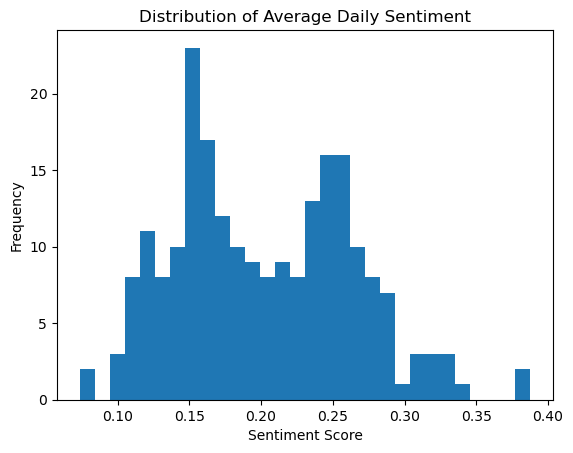

In [56]:
import matplotlib.pyplot as plt

plt.hist(merged['avg_sentiment'], bins=30)
plt.title("Distribution of Average Daily Sentiment")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

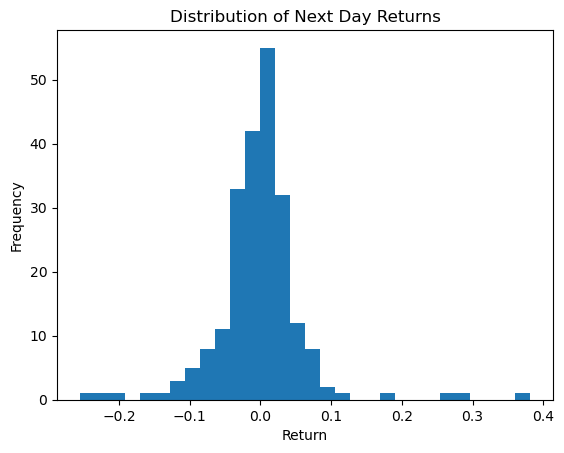

In [57]:
plt.hist(merged['next_day_return'], bins=30)
plt.title("Distribution of Next Day Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

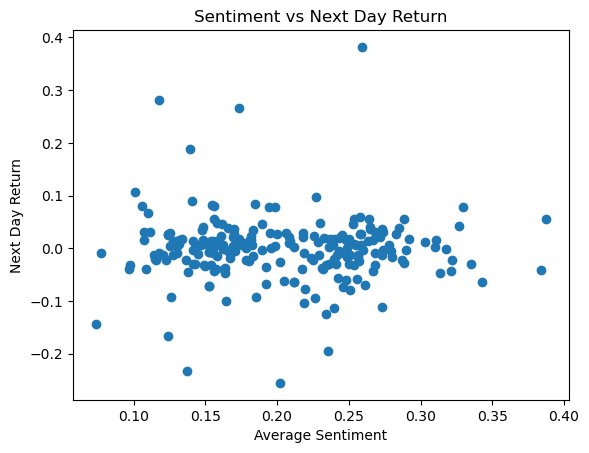

In [58]:
plt.scatter(merged['avg_sentiment'], merged['next_day_return'])
plt.xlabel("Average Sentiment")
plt.ylabel("Next Day Return")
plt.title("Sentiment vs Next Day Return")
plt.show()

In [64]:
merged.sort_values("next_day_return", ascending=False).head(1)

,avg_sentiment,Date,Close,High,Low,Open,Volume,next_day_return,target
77,0.259198,2021-09-10,44883.910156,47031.742188,44344.484375,46396.664062,39154666597,0.381922,1


Correlation WITH outlier

In [65]:
merged[['avg_sentiment', 'next_day_return']].corr()

,avg_sentiment,next_day_return
avg_sentiment,1.000000,-0.021878
next_day_return,-0.021878,1.000000


Correlation WITHOUT extreme moves (>20%)

In [66]:
filtered = merged[merged['next_day_return'].abs() < 0.2]
filtered[['avg_sentiment', 'next_day_return']].corr()

,avg_sentiment,next_day_return
avg_sentiment,1.000000,-0.038157
next_day_return,-0.038157,1.000000


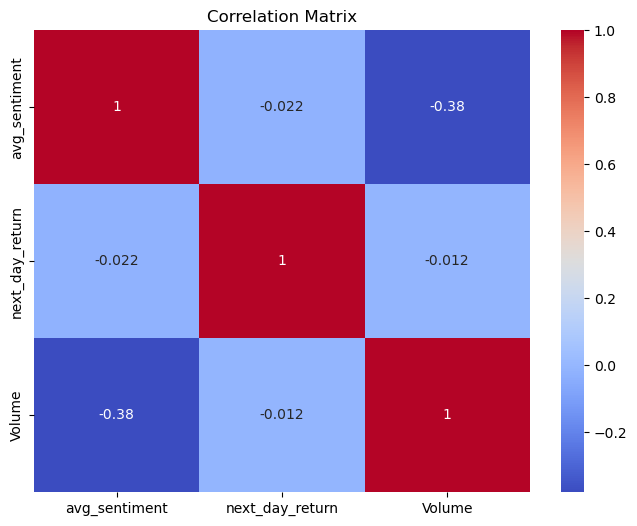

In [59]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    merged[['avg_sentiment', 'next_day_return', 'Volume']].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

Sentiment Over Time


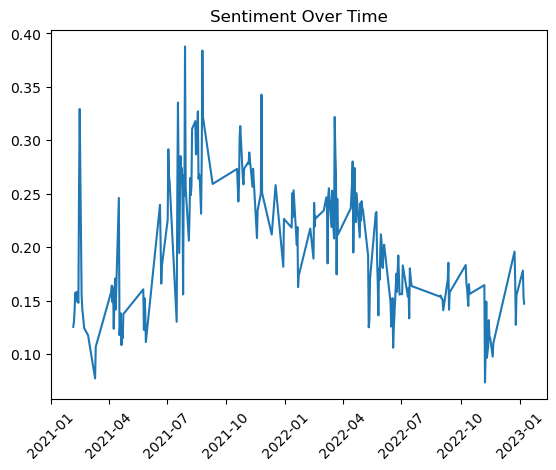

In [61]:
plt.plot(merged['Date'], merged['avg_sentiment'])
plt.title("Sentiment Over Time")
plt.xticks(rotation=45)
plt.show()

BTC Price Over Time

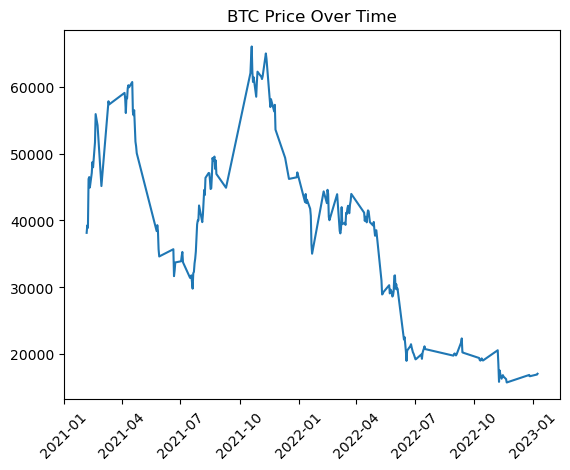

In [63]:
plt.plot(merged['Date'], merged['Close'])
plt.title("BTC Price Over Time")
plt.xticks(rotation=45)
plt.show()

creating  new lag sentiment features to capture delayed reaction


In [70]:
merged['sentiment_lag1'] = merged['avg_sentiment'].shift(1)
merged['sentiment_lag2'] = merged['avg_sentiment'].shift(2)
merged['sentiment_lag3'] = merged['avg_sentiment'].shift(3)

-Day Rolling Sentiment
We compute a 3-day and 7-day moving average of daily sentiment:
This represents the average sentiment over the last three days.
used to capture trend

In [73]:
merged['sentiment_3day'] = merged['avg_sentiment'].rolling(3).mean()
merged['sentiment_7day'] = merged['avg_sentiment'].rolling(7).mean()

Measures percentage price change from previous day.  

Measures intraday price fluctuation relative to opening price.  

Measures change in trading activity from previous day.  



In [77]:
merged['return_1d'] = merged['Close'].pct_change()
merged['volatility'] = (merged['High'] - merged['Low']) / merged['Open']
merged['volume_change'] = merged['Volume'].pct_change()

Log Transform to handle volume data

In [84]:
merged['log_volume'] = np.log1p(merged['Volume'])

In [85]:
merged.isnull().sum()

avg_sentiment      0
Date               0
Close              0
High               0
Low                0
Open               0
Volume             0
next_day_return    0
target             0
sentiment_lag1     0
sentiment_lag2     0
sentiment_lag3     0
sentiment_3day     0
sentiment_7day     0
return_1d          0
volatility         0
volume_change      0
log_volume         0
dtype: int64

In [86]:
merged = merged.dropna()

Define Feature Matrix. 

In [87]:
features = [
    'avg_sentiment',
    'sentiment_lag1',
    'sentiment_lag2',
    'sentiment_lag3',
    'sentiment_3day',
    'sentiment_7day',
    'return_1d',
    'volatility',
    'volume_change',
    'log_volume'
]

X = merged[features]
y = merged['target']

Time-Based Train–Test Split

To avoid look-ahead bias, the dataset is split chronologically.

All data before 1 august 2022 is used for training,
and data from 1 august 2022 onward is used for testing.

In [103]:
train = merged[merged['Date'] < '2022-08-01']
test  = merged[merged['Date'] >= '2022-08-01']
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']

In [104]:
X_train.head()

,avg_sentiment,sentiment_lag1,sentiment_lag2,sentiment_lag3,sentiment_3day,sentiment_7day,return_1d,volatility,volume_change,log_volume
0,0.256153,0.148022,0.158262,0.149422,0.187479,0.162682,0.034216,0.050369,0.014209,24.989442
1,0.329345,0.256153,0.148022,0.158262,0.244507,0.191166,-0.015851,0.051915,0.081703,25.067979
2,0.154621,0.329345,0.256153,0.148022,0.246707,0.193314,0.077896,0.027969,-0.324578,24.675561
3,0.143075,0.154621,0.329345,0.256153,0.209014,0.191272,0.081431,0.100170,0.219784,24.874235
4,0.124258,0.143075,0.154621,0.329345,0.140651,0.187677,-0.030075,0.148886,0.449747,25.245624


MODEL training

In [121]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [127]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [128]:
y_pred_rf = rf.predict(X_test)

In [131]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.6

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.44      0.53        18
           1       0.57      0.76      0.65        17

    accuracy                           0.60        35
   macro avg       0.62      0.60      0.59        35
weighted avg       0.62      0.60      0.59        35


Confusion Matrix:
 [[ 8 10]
 [ 4 13]]


In [117]:
importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values(ascending=False)

sentiment_lag3    0.131470
log_volume        0.121643
sentiment_lag2    0.112068
return_1d         0.104386
sentiment_3day    0.096134
volatility        0.096090
volume_change     0.095256
avg_sentiment     0.087411
sentiment_lag1    0.082276
sentiment_7day    0.073268
dtype: float64

In [132]:
import joblib

joblib.dump(rf, "btc_sentiment_model.pkl")

['btc_sentiment_model.pkl']